In [1]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# Retrain with your best Optuna params
best_xgb = XGBClassifier(
    n_estimators=191,
    max_depth=4,
    learning_rate=0.02378,
    subsample=0.7481,
    colsample_bytree=0.6780,
    eval_metric='logloss',
    random_state=42
)
best_xgb.fit(X_train, y_train)

print("Model trained successfully")
print("AUC:", round(roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]), 4))

# SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

Model trained successfully
AUC: 0.8487
SHAP values shape: (1409, 26)


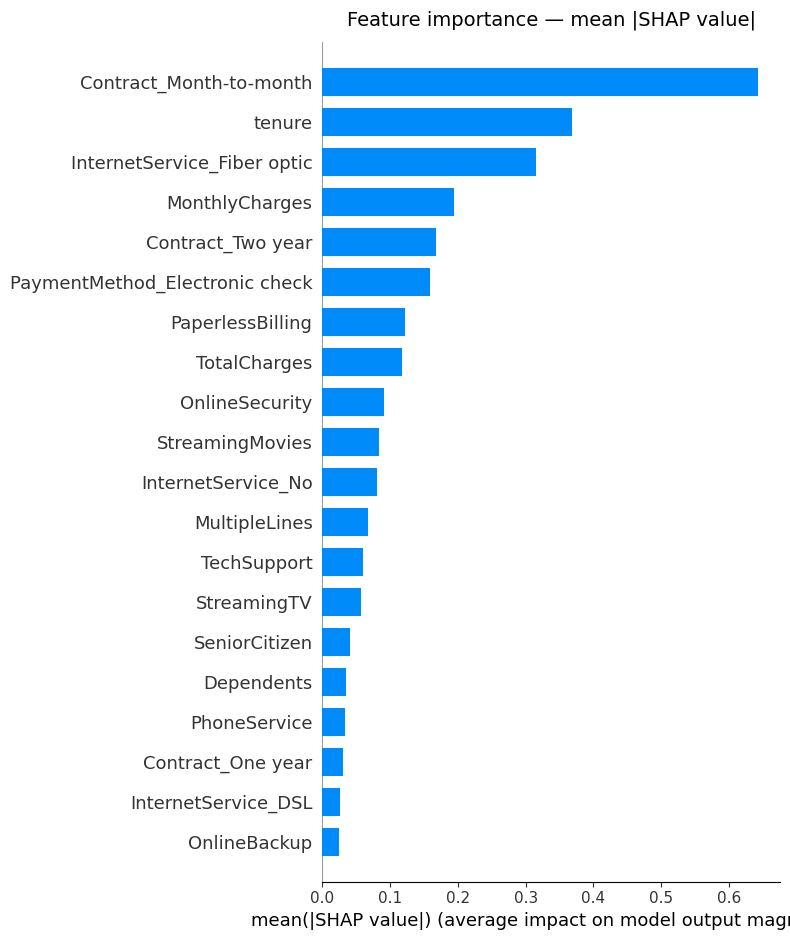

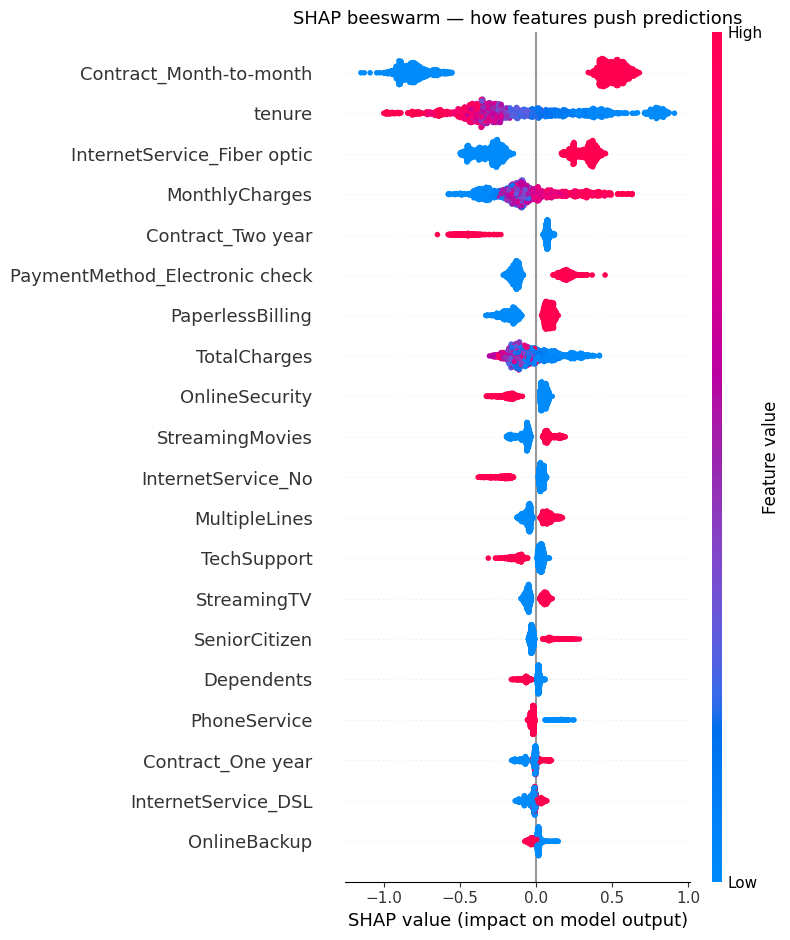

In [2]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    show=False
)
plt.title('Feature importance — mean |SHAP value|', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('../data/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot (shows direction of effect too)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP beeswarm — how features push predictions', fontsize=13)
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

Actual label: 1
Model prediction: 0
Churn probability: 0.34


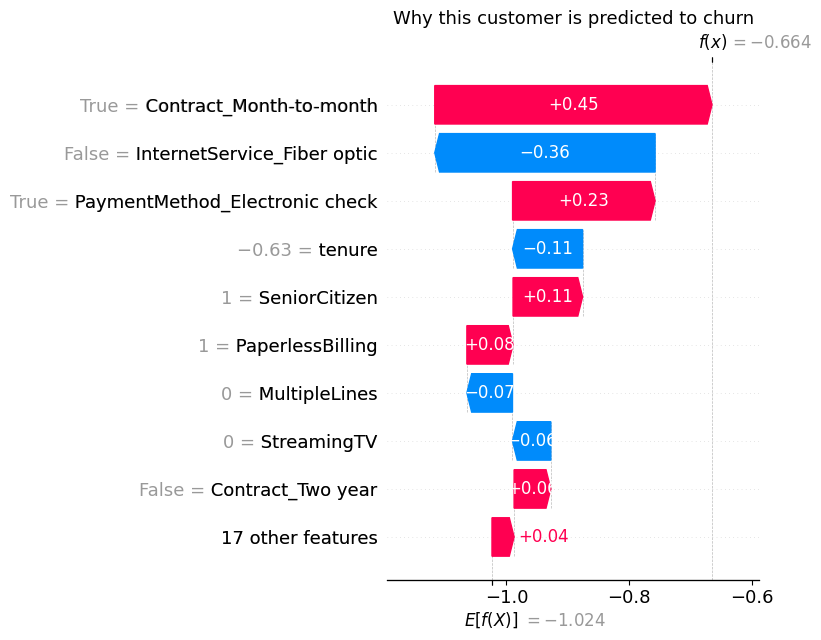

In [3]:
# Pick a customer who actually churned
churn_idx = y_test[y_test == 1].index[0]
pos = X_test.index.get_loc(churn_idx)

print("Actual label:", y_test.iloc[pos])
print("Model prediction:", best_xgb.predict(X_test.iloc[[pos]])[0])
print("Churn probability:", 
      best_xgb.predict_proba(X_test.iloc[[pos]])[0][1].round(3))

# Waterfall plot — shows exactly why this customer is high risk
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[pos],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title('Why this customer is predicted to churn', fontsize=13)
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

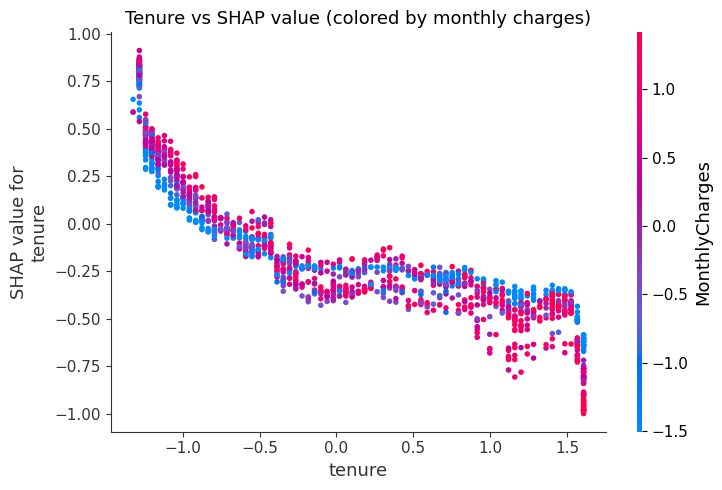

In [4]:
# Shows how tenure interacts with monthly charges
shap.dependence_plot(
    'tenure', shap_values, X_test,
    interaction_index='MonthlyCharges',
    show=False
)
plt.title('Tenure vs SHAP value (colored by monthly charges)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## Business insights from SHAP analysis

### Top churn drivers:
1. **Contract type** — month-to-month contracts have the highest 
   positive SHAP values, meaning they push churn probability up most

2. **Tenure** — short tenure customers are high risk.
   The model learns that customers who stay past ~12 months are 
   much less likely to leave.

3. **Monthly charges** — high monthly charges increase churn risk, 
   especially when combined with short tenure.

### Recommendation:
- Offer incentives to convert month-to-month customers to annual contracts
- Prioritize retention campaigns for customers in their first 6 months
- Consider loyalty discounts for high-spending short-tenure customers

This model can predict churn risk per customer — enabling proactive,
targeted interventions rather than blanket retention campaigns.